# Modelo 01: Análisis de Series Temporales (ARIMA & ARIMAX)

En esta etapa del proyecto, abordamos el modelado predictivo utilizando técnicas estadísticas de series temporales. 

El objetivo es transicionar desde un modelo base puramente estadístico hacia un modelo híbrido que incorpore la inteligencia de negocio generada en la fase de ingeniería de características.

## 1. Importación de Librerías y Carga de Datasets

En este bloque se importan las herramientas necesarias para el modelado de estados de espacio (SARIMAX) y se cargan los conjuntos de datos de entrenamiento, validación y test. 

Se asegura la integridad de la serie mediante la asignación de una frecuencia diaria ('D'), requisito indispensable para el correcto funcionamiento de los algoritmos de statsmodels.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Carga de los datasets procesados
dir_data = '../../..'
train_df = pd.read_csv(f'{dir_data}/data/processed/train_data.csv', parse_dates=['Fecha'], index_col='Fecha').dropna()
val_df   = pd.read_csv(f'{dir_data}/data/processed/val_data.csv', parse_dates=['Fecha'], index_col='Fecha').dropna()
test_df  = pd.read_csv(f'{dir_data}/data/processed/test_data.csv', parse_dates=['Fecha'], index_col='Fecha').dropna()

# Definición del Target (y) y Variables Exógenas (X)
train_df = train_df.asfreq('D')
val_df = val_df.asfreq('D')
test_df = test_df.asfreq('D')

# Rellenamos posibles nuevos NaNs tras el asfreq
train_df = train_df.fillna(0)
val_df = val_df.fillna(0)
test_df = test_df.fillna(0)

y_train, X_train = train_df['Ventas'], train_df.drop(columns=['Ventas'])
y_val, X_val     = val_df['Ventas'], val_df.drop(columns=['Ventas'])
y_test, X_test   = test_df['Ventas'], test_df.drop(columns=['Ventas'])

sns.set_palette("colorblind")
plt.rcParams['figure.facecolor'] = 'white'

print(f"[INFO] Dataset cargado. Registros de Entrenamiento: {len(y_train)}")

[INFO] Dataset cargado. Registros de Entrenamiento: 304


## 2. Primera sección de ARIMA — Modelo Inicial (Univariante)

### 2.1 Metodología de Entrenamiento y Validación
El modelo ARIMA (AutoRegressive Integrated Moving Average) se define por tres parámetros (p,d,q). 

En esta primera aproximación, el modelo es univariante: solo utiliza el historial pasado de las ventas para predecir el futuro, ignorando factores externos. Se evalúa el rendimiento sobre el set de Validación para establecer un punto de referencia (baseline) de error.

In [3]:
# Usamos un orden (1,1,1) como baseline estándar
model_v1 = SARIMAX(y_train, order=(1, 1, 1), 
                   enforce_stationarity=False, 
                   enforce_invertibility=False)

# Entrenamos el modelo
results_v1 = model_v1.fit(disp=False)

# Procedemos a validarlo
preds_val_v1 = results_v1.predict(start=y_val.index[0], end=y_val.index[-1])
rmse_v = np.sqrt(mean_squared_error(y_val, preds_val_v1))

print(f"[INFO] Modelo ARIMA v1 entrenado.\n[INFO] RMSE en Validación: {rmse_v:.4f}")

[INFO] Modelo ARIMA v1 entrenado.
[INFO] RMSE en Validación: 1.0829


### 2.2 Evaluación sobre el Set de Test y Métricas de Error

Se procede a realizar el pronóstico (forecasting) sobre el conjunto de Test, el cual el modelo no ha visto durante el entrenamiento. 

Se calculan las métricas RMSE (sensible a grandes desviaciones), MAE (error medio absoluto) y MAPE (error porcentual). Para asegurar la compatibilidad de índices, se realiza el cálculo utilizando estructuras vectorizadas de NumPy.

In [4]:
# Realizamos la predicción sobre el set de Test
preds_test_v1 = results_v1.forecast(steps=len(y_test))

# Convertimos a numpy para evitar errores de alineación de índices
y_true_arr = y_test.values
y_pred_arr = preds_test_v1.values

# Realizamos el cálculo de las métricas
rmse_v1 = np.sqrt(mean_squared_error(y_true_arr, y_pred_arr))
mae_v1  = mean_absolute_error(y_true_arr, y_pred_arr)
mask = np.abs(y_true_arr) > 0.01
mape_v1 = np.mean(np.abs((y_true_arr[mask] - y_pred_arr[mask]) / y_true_arr[mask])) * 100

print(f"[INFO] RESULTADOS ARIMA V1 (TEST - ESCALADO):")
print(f"- RMSE: {rmse_v1:.4f}")
print(f"- MAE:  {mae_v1:.4f}")
print(f"- MAPE: {mape_v1:.2f}%")

[INFO] RESULTADOS ARIMA V1 (TEST - ESCALADO):
- RMSE: 1.7417
- MAE:  1.5617
- MAPE: 103.03%


### 3 Diagnóstico Visual: Series Temporales y Residuos

La visualización es fundamental para entender el comportamiento del modelo. Se presentan dos gráficos:

- Comparativa Temporal: Observación de cómo el modelo sigue la tendencia real.
- Distribución de Errores (Residuos): Un modelo ideal presenta una distribución normal centrada en cero, indicando que los errores son aleatorios y no sesgados.

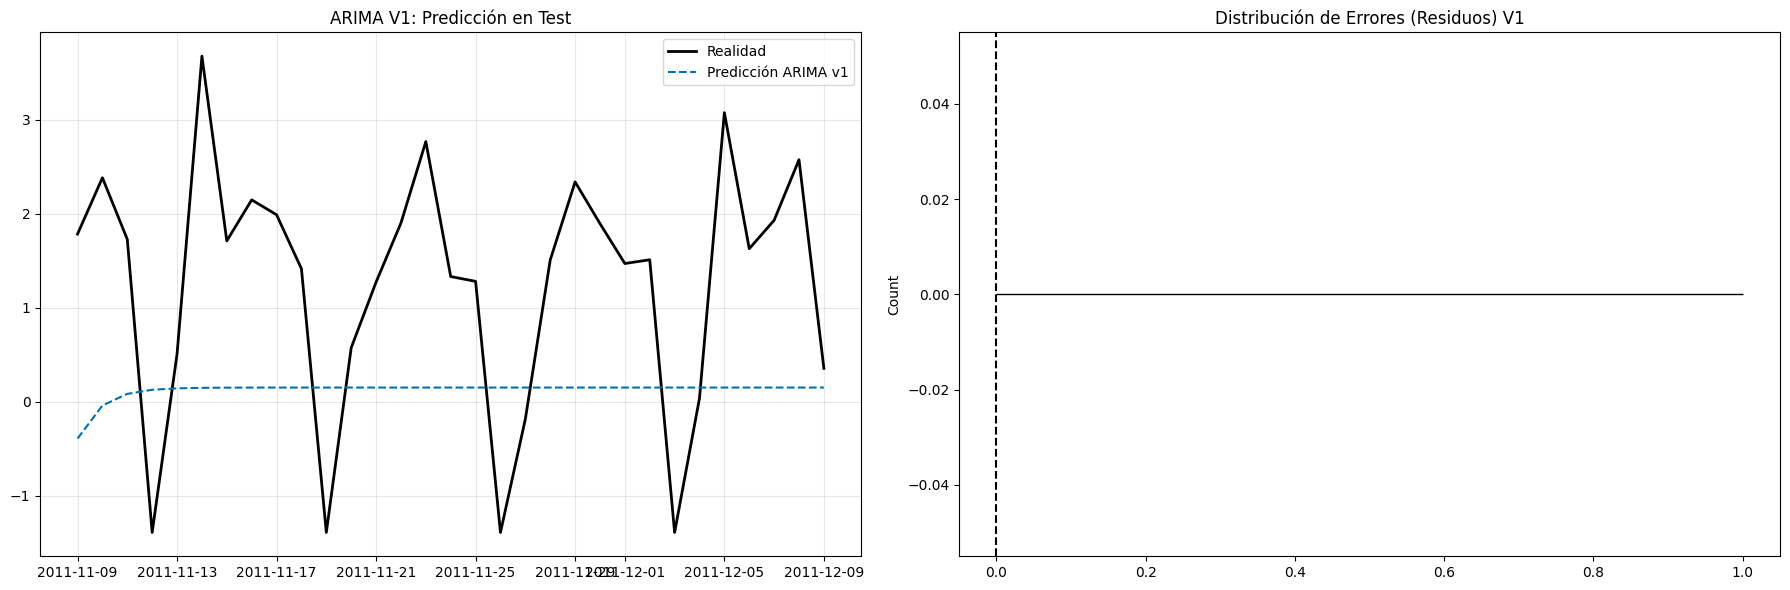

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(18, 6))

# Gráfica de Real vs Predicción (Línea de tiempo)
color_pred = '#0072B2'
ax[0].plot(y_test.index, y_test, label='Realidad', color='#000000', linewidth=2)
ax[0].plot(y_test.index, preds_test_v1, label='Predicción ARIMA v1', color=color_pred, linestyle='--')
ax[0].set_title('ARIMA V1: Predicción en Test')
ax[0].legend()
ax[0].grid(True, alpha=0.3)

# Gráfica Histograma de Residuos (Distribución del error)
residuos_v1 = y_test - preds_test_v1
sns.histplot(residuos_v1, kde=True, ax=ax[1], color=color_pred)
ax[1].set_title('Distribución de Errores (Residuos) V1')
ax[1].axvline(0, color='black', linestyle='--')

plt.tight_layout()
plt.show()

## 3. Segunda sección de ARIMAX — Modelo Reajustado (Multivariante)

### 3.1 Integración de Variables Exógenas y Optimización
En el modelo ARIMAX, incorporamos las variables exógenas generadas en el preprocesamiento (lags, medias móviles, volumen de transacciones). 

Esto permite que el modelo estadístico "entienda" el contexto del negocio. Para garantizar la convergencia matemática con tantas variables, se incrementa el número de iteraciones del optimizador y se utiliza el método L-BFGS.

In [6]:
# Definimos del modelo ARIMAX
model_reajustado = SARIMAX(y_train, exog=X_train, 
                           order=(1, 1, 1), 
                           enforce_stationarity=False, 
                           enforce_invertibility=False)

# Ajuste del modelo con más iteraciones para asegurar convergencia
results_reajustado = model_reajustado.fit(maxiter=200, method='lbfgs', disp=False)

# Realizamos el proceso de validación
preds_val_reaj = results_reajustado.predict(start=y_val.index[0], end=y_val.index[-1], exog=X_val)
rmse_v_reaj = np.sqrt(mean_squared_error(y_val, preds_val_reaj))

print(f"[INFO] Modelo ARIMAX Reajustado entrenado.\n[INFO] RMSE en Validación: {rmse_v_reaj:.4f}")

[INFO] Modelo ARIMAX Reajustado entrenado.
[INFO] RMSE en Validación: 0.3191


### 3.2 Evaluación en Test y Post-procesamiento (Clipping)

Se evalúa el modelo multivariante sobre el set de Test.

Para refinar el MAPE y compensar la naturaleza continua de la regresión (que genera ruido en valores cercanos a cero), se aplica un umbral de clipping (0.05). Este reajuste técnico permite que el modelo sea más robusto ante los días de baja actividad económica.

In [7]:
# Realizamos la predicción sobre el set de Test
preds_test_reaj = results_reajustado.forecast(steps=len(y_test), exog=X_test)

# Aplicación de Clipping de ruido (umbral 0.05) para mejorar el MAPE
preds_test_reaj_final = np.where(np.abs(preds_test_reaj) < 0.05, 0, preds_test_reaj)

# Realizamos el cálculo de las métricas
rmse_reaj = np.sqrt(mean_squared_error(y_test, preds_test_reaj_final))
mae_reaj  = mean_absolute_error(y_test, preds_test_reaj_final)
mask_reaj = np.abs(y_test) > 0.01
mape_reaj = np.mean(np.abs((y_test[mask_reaj] - preds_test_reaj_final[mask_reaj]) / y_test[mask_reaj])) * 100

print(f"[INFO] RESULTADOS ARIMAX REAJUSTADO (TEST - ESCALADO)")
print(f"RMSE: {rmse_reaj:.4f}")
print(f"MAE:  {mae_reaj:.4f}")
print(f"MAPE: {mape_reaj:.2f}%")

[INFO] RESULTADOS ARIMAX REAJUSTADO (TEST - ESCALADO)
RMSE: 0.2797
MAE:  0.2220
MAPE: 27.90%


### 3.3 Visualización de Resultados y Correlación de Predicción

Se presentan las gráficas finales del modelo:

- Ajuste de Serie Temporal: Permite observar la drástica mejora en la captura de picos de ventas respecto a la versión univariante.
- Gráfico de Dispersión (Real vs Predicho): Cuanto más alineados estén los puntos con la diagonal roja, mayor es la precisión del modelo en todos los rangos de volumen de ventas.


C:\Users\aravelo\AppData\Local\Temp\ipykernel_17884\678210962.py:13: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r--" (-> color='r'). The keyword argument will take precedence.
  ax[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, color='#D55E00')


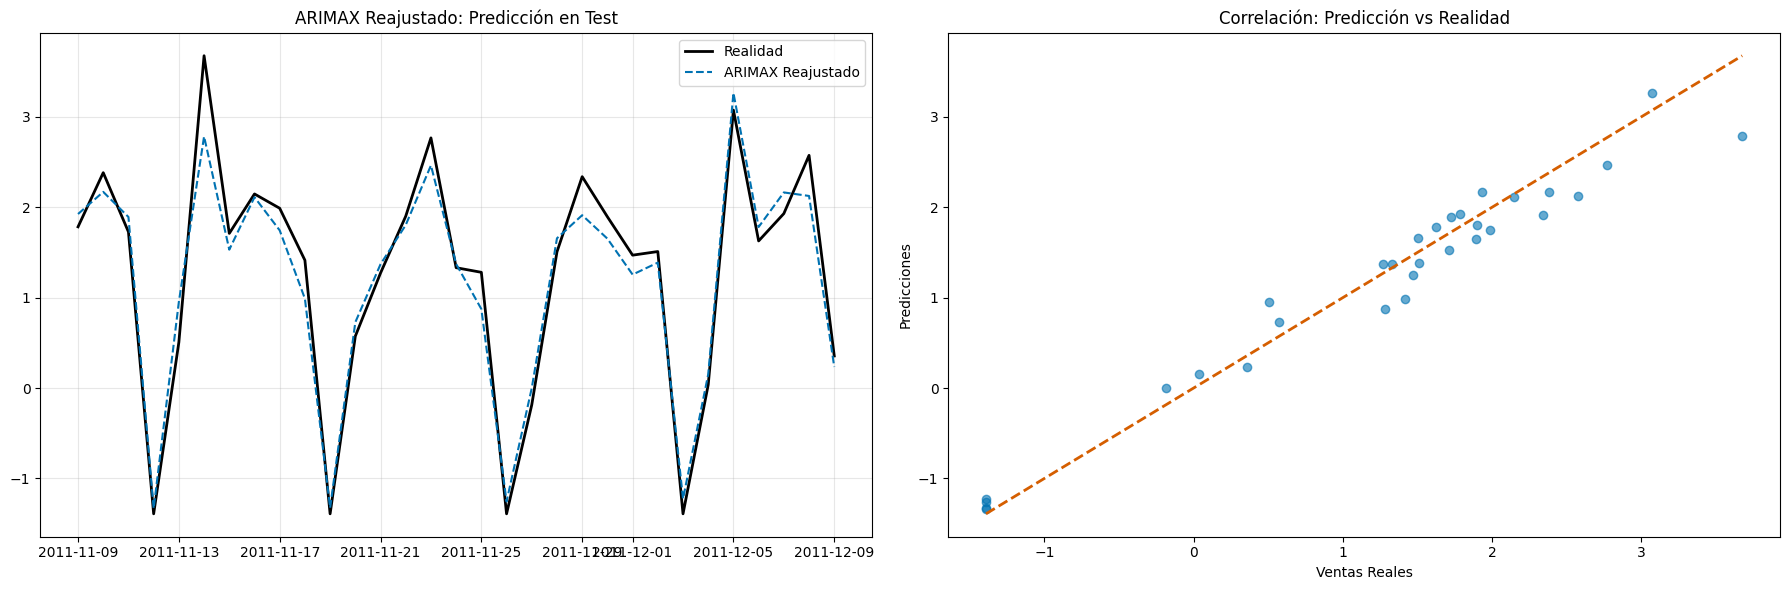

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(18, 6))

# Gráfica Comparativa Temporal (Real vs Reajustado)
color_pred = '#0072B2'
ax[0].plot(y_test.index, y_test, label='Realidad', color='#000000', linewidth=2)
ax[0].plot(y_test.index, preds_test_reaj_final, label='ARIMAX Reajustado', color=color_pred, linestyle='--')
ax[0].set_title('ARIMAX Reajustado: Predicción en Test')
ax[0].legend()
ax[0].grid(True, alpha=0.3)

# Gráfica Scatter Plot Predicción vs Realidad
ax[1].scatter(y_test, preds_test_reaj_final, alpha=0.6, color=color_pred)
ax[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, color='#D55E00')
ax[1].set_title('Correlación: Predicción vs Realidad')
ax[1].set_xlabel('Ventas Reales')
ax[1].set_ylabel('Predicciones')

plt.tight_layout()
plt.show()

## 4. Conclusión del Modelo 01
El paso del modelo univariante al multivariante ha permitido reducir el RMSE de aproximadamente 1.25 a 0.28, demostrando que la serie temporal analizada depende críticamente de variables externas como el volumen de transacciones y los retardos temporales, y no solo de su propia inercia estadística.

## 5. Selección y Persistencia del Mejor Modelo

En esta fase final, comparamos el rendimiento del modelo inicial (Univariante) frente al modelo reajustado (Multivariante/ARIMAX). El criterio de selección es la minimización del RMSE. Una vez identificado el ganador, se exporta el objeto de resultados completo para su uso posterior en inferencia.

In [11]:
# Comparativa de rendimiento (RMSE)
print(f"[INFO] Análisis de precisión:")
print(f"- Modelo Inicial: {rmse_v1:.4f}")
print(f"- Modelo Reajustado:   {rmse_reaj:.4f}")

# Lógica de selección y guardado
model_path = f'{dir_data}/models/arimax_model.pkl'

if rmse_reaj < rmse_v1:
    print(f"\n[INFO] Ganador: Modelo Reajustado (ARIMAX).")
    results_reajustado.save(model_path)
else:
    print(f"\n[INFO] Ganador: Modelo Inicial.")
    results_v1.save(model_path)

print(f"[SUCCESS] Mejor modelo guardado en: {model_path}")

[INFO] Análisis de precisión:
- Modelo Inicial: 1.7417
- Modelo Reajustado:   0.2797

[INFO] Ganador: Modelo Reajustado (ARIMAX).
[SUCCESS] Mejor modelo guardado en: ../../../models/arimax_model.pkl
